# Proyecto Computación I – Gemelo Digital de Aruba (módulo energético)
## Análisis exploratorio (EDA) e integración de fuentes
**Fuentes**
1. ERA5 (CSV): `valid_time, latitude, longitude, u100, v100, ssrd` (viento a 100 m y radiación)
2. `aruba_stations.json`: metadatos de estaciones
3. `aruba_lecturas.json`: lecturas meteorológicas de las estaciones

**Qué hace este notebook (OE-01 / RF-03 / RF-04 del anteproyecto):** carga, calidad de datos, frecuencia de muestreo,
distribuciones, relación entre estaciones, relación estaciones ↔ ERA5, y una primera estimación de potencia del parque
(para ver cuánto tiempo estaría por debajo del umbral de 500 kW).

## 0. Configuración

In [5]:
from google.colab import drive
import os

# Montar Google Drive
drive.mount('/content/drive')

# Buscaremos automáticamente la carpeta donde se encuentra este notebook o los archivos dentro de Drive
# Puedes ajustar esta variable si tu carpeta tiene un nombre específico en Drive
# Por defecto, buscaremos el archivo 'aruba_stations.json' para definir la ruta base.

def buscar_ruta_base(archivo_clave='aruba_stations.json'):
    for root, dirs, files in os.walk('/content/drive/My Drive'):
        if archivo_clave in files:
            print(f"¡Encontrado! Carpeta del proyecto: {root}")
            return root
    return None

folder_path = buscar_ruta_base()
if folder_path:
    # Cambiar el directorio de trabajo actual a la carpeta donde están los datos
    os.chdir(folder_path)
    print("Directorio de trabajo cambiado a:", os.getcwd())
else:
    print("⚠️ No se encontró 'aruba_stations.json' automáticamente. Por favor, asegúrate de que el archivo esté en tu Drive.")

Mounted at /content/drive
¡Encontrado! Carpeta del proyecto: /content/drive/My Drive/Colab Notebooks/Aruba-ProyectoComputacionI
Directorio de trabajo cambiado a: /content/drive/My Drive/Colab Notebooks/Aruba-ProyectoComputacionI


In [2]:
import os, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 160)

# ---- RUTAS: ajusta los nombres si hace falta ----
PATH_ERA5     = "era5_aruba.csv"          # fuente 1 (CSV)
PATH_STATIONS = "aruba_stations.json"
PATH_LECTURAS = "train_aruba_lecturas.json"

TZ_LOCAL     = "America/Aruba"   # UTC-4, sin horario de verano
ALTURA_MEDIDA_ESTACION_M = 10    # SUPUESTO: altura del anemómetro de las estaciones
ALTURA_BUJE_M = 100              # altura de referencia ERA5
UMBRAL_ALERTA_KW = 500           # RF-13
N_TURBINAS, P_NOMINAL_KW = 10, 3000   # Vader Piet: 10 x 3 MW

In [3]:
# Si estás en Colab y los ficheros no están en el entorno, se piden por pantalla.
# (Alternativa: monta Drive y pon aquí las rutas completas.)
faltan = [p for p in (PATH_ERA5, PATH_STATIONS, PATH_LECTURAS) if not os.path.exists(p)]
if faltan:
    try:
        from google.colab import files
        print("Sube estos ficheros:", faltan)
        up = files.upload()
        print("Subidos:", list(up))
    except ImportError:
        raise FileNotFoundError(f"No encuentro: {faltan}")

Sube estos ficheros: ['era5_aruba.csv', 'aruba_stations.json', 'train_aruba_lecturas.json']


Subidos: []


## 1. Carga de estaciones y lecturas

In [6]:
stations = pd.read_json(PATH_STATIONS)
lect = pd.read_json(PATH_LECTURAS, convert_dates=False)
lect["timestamp"] = pd.to_datetime(lect["timestamp"], utc=True, errors="coerce")

print("Estaciones:", stations.shape, "| Lecturas:", lect.shape)
display(stations)
display(lect.head())
print(lect.dtypes)

Estaciones: (12, 8) | Lecturas: (421584, 11)


,id,name,code,latitude,longitude,elevation_m,district,is_active
0,4ca4c103-894d-4f59-a911-f3abb8077e3c,Alto Vista,WS-ALT-11,12.5912,-70.0374,25,Noord,True
1,de2ee07b-de63-49db-a669-64177a688bbf,Queen Beatrix Airport,WS-APT-02,12.5042,-70.0031,18,Oranjestad,True
2,acb2fa5c-518a-4a38-b68d-bf8e3b041ccf,Arikok National Park,WS-ARK-10,12.5009,-69.9538,120,Santa Cruz,True
3,f678bd98-07d3-459d-bd4d-7aaba7051847,Hooiberg Summit,WS-HOO-07,12.5204,-69.9992,165,Santa Cruz,True
4,8f0185fa-a4c3-41c1-8f3b-d08f4f6aece0,Malmok,WS-MAL-12,12.5961,-70.0489,6,Noord,True
5,09ea9cd3-4d28-4049-9dfb-3c5bd5849e9c,Noord,WS-NRD-03,12.5645,-70.0319,15,Noord,True
6,c3a0e9a3-36fe-4c50-8c3e-e100045b4a63,Oranjestad Central,WS-ORA-01,12.5201,-70.0371,5,Oranjestad,True
7,5c5c4158-91cb-4073-ab4c-9bb10037dc16,Paradera,WS-PAR-06,12.5354,-70.0050,30,Paradera,True
8,d8a1ce0a-873e-436f-9c1d-a2179ee2601c,Palm Beach,WS-PLM-04,12.5626,-70.0417,3,Noord,True
9,82a31d3a-9895-42e5-8ea0-11e8cb15b964,Savaneta,WS-SAV-08,12.4526,-69.9497,4,Savaneta,True


,id,station_id,timestamp,temperature_c,humidity_pct,wind_speed_kmh,wind_direction_deg,pressure_hpa,precipitation_mm,visibility_km,uv_index
0,7d227091-7c79-43e2-ad53-ba4bb2a20299,09ea9cd3-4d28-4049-9dfb-3c5bd5849e9c,2026-03-31 22:00:00+00:00,30.5,71.6,21.2,45.3,1016.0,0.0,11.7,0.0
1,5b9f3e1c-e410-4bc7-a0f5-ef4752ddfee9,4ca4c103-894d-4f59-a911-f3abb8077e3c,2026-03-31 22:00:00+00:00,30.4,71.8,21.5,45.6,1016.0,0.0,12.3,0.0
2,030f90af-d5fd-4554-bc71-5d947ba5663e,5c5c4158-91cb-4073-ab4c-9bb10037dc16,2026-03-31 22:00:00+00:00,30.1,71.8,22.1,46.2,1016.0,0.0,11.9,0.0
3,39b0eab6-66c8-4a5c-987b-63a119e533d1,82a31d3a-9895-42e5-8ea0-11e8cb15b964,2026-03-31 22:00:00+00:00,30.3,71.7,20.8,45.4,1016.0,0.0,11.8,0.0
4,50708c07-12b0-4c63-8a82-7527e03e6f2a,8f0185fa-a4c3-41c1-8f3b-d08f4f6aece0,2026-03-31 22:00:00+00:00,30.5,71.7,20.7,45.0,1016.0,0.0,12.2,0.0


id                                 object
station_id                         object
timestamp             datetime64[ns, UTC]
temperature_c                     float64
humidity_pct                      float64
wind_speed_kmh                    float64
wind_direction_deg                float64
pressure_hpa                      float64
precipitation_mm                  float64
visibility_km                     float64
uv_index                          float64
dtype: object


### 1.1 Calidad de datos: nulos, duplicados, integridad referencial

In [7]:
resumen = pd.DataFrame({"nulos": lect.isna().sum(), "% nulos": (lect.isna().mean()*100).round(2),
                        "únicos": lect.nunique()})
display(resumen)

print("Duplicados por id:                 ", lect["id"].duplicated().sum())
print("Duplicados por (station_id, time): ", lect.duplicated(["station_id", "timestamp"]).sum())
print("Duplicados totales (fila completa):", lect.drop(columns="id").duplicated().sum())
print("Timestamps no parseables:          ", lect["timestamp"].isna().sum())

huerfanas = set(lect["station_id"]) - set(stations["id"])
print("station_id sin estación en el JSON:", len(huerfanas))
print("Estaciones sin lecturas:", set(stations["id"]) - set(lect["station_id"]))
print("Estaciones inactivas:", stations.loc[~stations["is_active"], "name"].tolist())

,nulos,% nulos,únicos
id,0,0.0,421584
station_id,0,0.0,12
timestamp,0,0.0,26204
temperature_c,0,0.0,135
humidity_pct,0,0.0,353
wind_speed_kmh,0,0.0,411
wind_direction_deg,0,0.0,552
pressure_hpa,0,0.0,172
precipitation_mm,0,0.0,86
visibility_km,0,0.0,85


Duplicados por id:                  0
Duplicados por (station_id, time):  107136
Duplicados totales (fila completa): 107136
Timestamps no parseables:           0
station_id sin estación en el JSON: 0
Estaciones sin lecturas: set()
Estaciones inactivas: []


In [8]:
# Limpieza básica (RF-03): ordenar, quitar duplicados, unir con metadatos
lect = (lect.dropna(subset=["timestamp"])
            .drop_duplicates(["station_id", "timestamp"])
            .sort_values(["station_id", "timestamp"]).reset_index(drop=True))

df = lect.merge(stations.rename(columns={"id": "station_id", "name": "station"}),
                on="station_id", how="left")
df["wind_ms"] = df["wind_speed_kmh"] / 3.6        # km/h -> m/s
df["local_time"] = df["timestamp"].dt.tz_convert(TZ_LOCAL)
df["hour"] = df["local_time"].dt.hour
df["month"] = df["local_time"].dt.month

# Estimación de viento a 100 m con ley potencial (alpha=1/7 como primera aproximación)
df["wind100_est_ms"] = df["wind_ms"] * (ALTURA_BUJE_M / ALTURA_MEDIDA_ESTACION_M) ** (1/7)

print("Periodo:", df["timestamp"].min(), "→", df["timestamp"].max())
print("Días cubiertos:", (df["timestamp"].max() - df["timestamp"].min()).days)

Periodo: 2026-03-31 22:00:00+00:00 → 2026-06-30 21:35:00+00:00
Días cubiertos: 90


### 1.2 Frecuencia de muestreo y huecos (clave para la rejilla de 5 min)

In [9]:
dt = df.groupby("station_id")["timestamp"].diff().dropna()
print("Intervalo entre lecturas (todas las estaciones):")
display(dt.dt.total_seconds().div(60).describe().round(2).to_frame("minutos"))
print("Intervalos más frecuentes (min):")
display(dt.dt.total_seconds().div(60).round(2).value_counts().head(8).to_frame("n"))

cnt = df.groupby("station").agg(n=("id", "size"), inicio=("timestamp", "min"), fin=("timestamp", "max"),
                                elev=("elevation_m", "first"), distrito=("district", "first"))
display(cnt.sort_values("elev"))

paso_tipico = dt.median()
huecos = dt[dt > 3 * paso_tipico]
print(f"Paso típico: {paso_tipico} | huecos > 3x paso: {len(huecos)}")

Intervalo entre lecturas (todas las estaciones):


,minutos
count,314436.0
mean,5.0
std,0.0
min,5.0
25%,5.0
50%,5.0
75%,5.0
max,5.0


Intervalos más frecuentes (min):


,n
timestamp,
5.0,314436


,n,inicio,fin,elev,distrito
station,,,,,
Palm Beach,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,3,Noord
Savaneta,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,4,Savaneta
Oranjestad Central,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,5,Oranjestad
Malmok,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,6,Noord
San Nicolaas,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,8,San Nicolaas
Noord,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,15,Noord
Queen Beatrix Airport,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,18,Oranjestad
Alto Vista,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,25,Noord
Paradera,26204,2026-03-31 22:00:00+00:00,2026-06-30 21:35:00+00:00,30,Paradera


Paso típico: 0 days 00:05:00 | huecos > 3x paso: 0


## 2. Estadística descriptiva y valores anómalos

In [10]:
VARS = ["temperature_c", "humidity_pct", "wind_speed_kmh", "wind_direction_deg",
        "pressure_hpa", "precipitation_mm", "visibility_km", "uv_index"]
display(df[VARS].describe().T.round(2))

# Rangos físicos plausibles -> marca inconsistencias
RANGOS = {"temperature_c": (15, 45), "humidity_pct": (0, 100), "wind_speed_kmh": (0, 150),
          "wind_direction_deg": (0, 360), "pressure_hpa": (980, 1040), "precipitation_mm": (0, 200),
          "visibility_km": (0, 50), "uv_index": (0, 16)}
fuera = {v: int(((df[v] < lo) | (df[v] > hi)).sum()) for v, (lo, hi) in RANGOS.items()}
print("Valores fuera de rango físico:", fuera)

# Outliers por IQR
def n_outliers_iqr(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return int(((s < q1 - 1.5*i) | (s > q3 + 1.5*i)).sum())
print("Outliers IQR:", {v: n_outliers_iqr(df[v].dropna()) for v in VARS})

,count,mean,std,min,25%,50%,75%,max
temperature_c,314448.0,29.49,2.69,22.1,27.2,29.6,31.9,35.5
humidity_pct,314448.0,75.01,5.96,62.3,69.4,74.9,80.3,98.7
wind_speed_kmh,314448.0,23.98,3.76,12.2,21.5,23.7,26.0,53.4
wind_direction_deg,314448.0,45.14,6.05,15.9,41.6,45.1,48.6,72.5
pressure_hpa,314448.0,1015.42,0.90,999.9,1015.1,1015.5,1015.9,1017.0
precipitation_mm,314448.0,0.00,0.13,0.0,0.0,0.0,0.0,20.7
visibility_km,314448.0,12.00,0.32,0.5,11.8,12.0,12.2,13.4
uv_index,314448.0,2.54,3.10,0.0,0.0,0.0,5.7,9.3


Valores fuera de rango físico: {'temperature_c': 0, 'humidity_pct': 0, 'wind_speed_kmh': 0, 'wind_direction_deg': 0, 'pressure_hpa': 0, 'precipitation_mm': 0, 'visibility_km': 0, 'uv_index': 0}
Outliers IQR: {'temperature_c': 0, 'humidity_pct': 20, 'wind_speed_kmh': 6164, 'wind_direction_deg': 9518, 'pressure_hpa': 1748, 'precipitation_mm': 446, 'visibility_km': 4068, 'uv_index': 0}


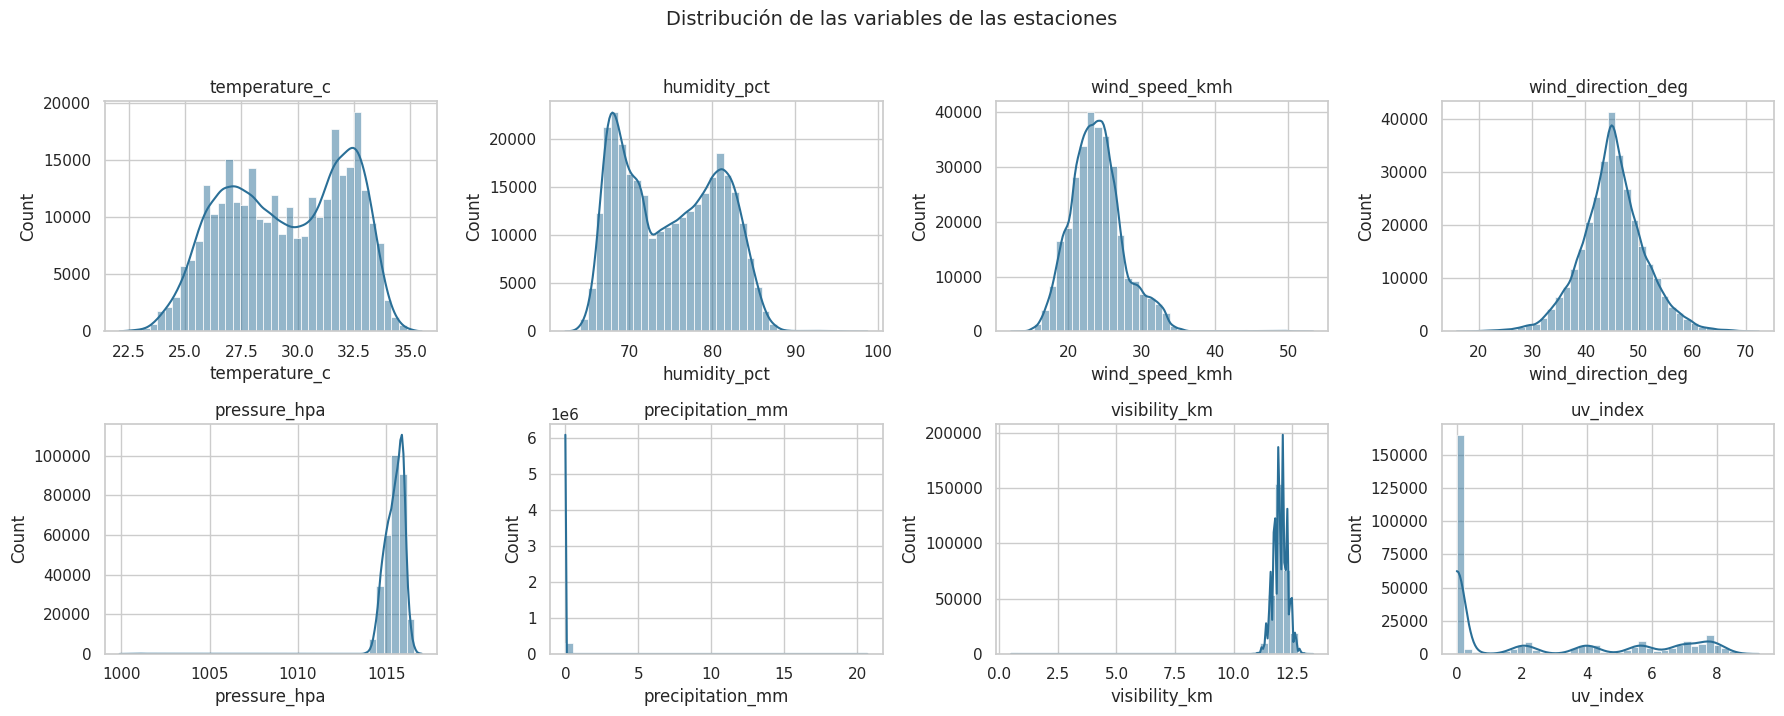

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, v in zip(axes.ravel(), VARS):
    sns.histplot(df[v].dropna(), bins=40, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(v)
plt.suptitle("Distribución de las variables de las estaciones", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

## 3. Comportamiento temporal

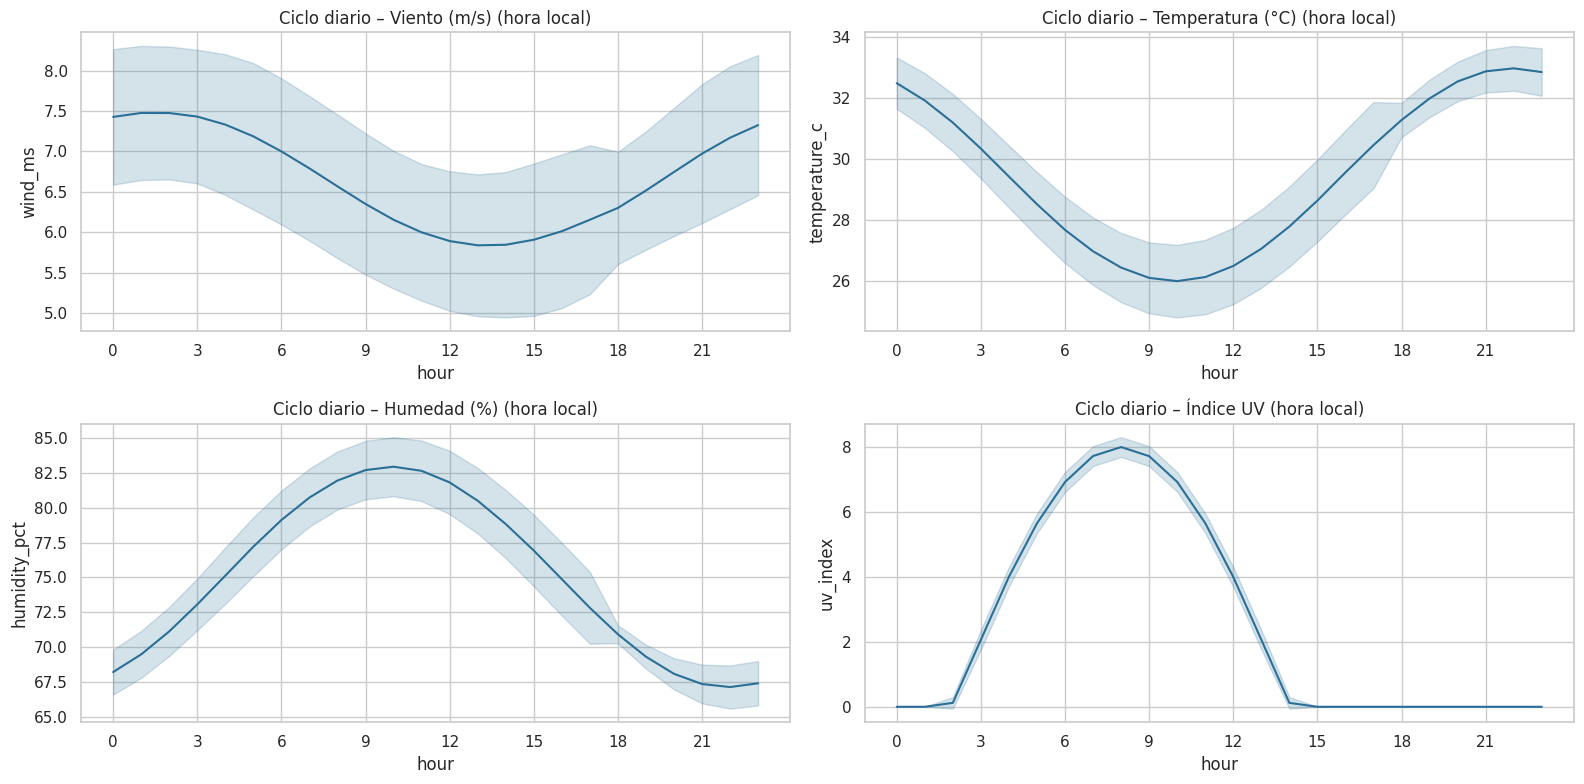

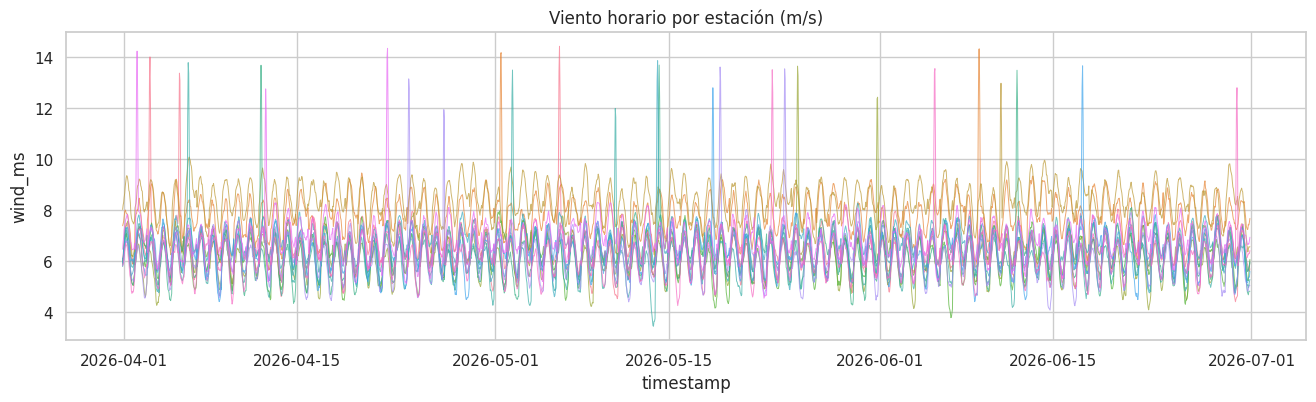

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, v, t in zip(axes.ravel(),
                    ["wind_ms", "temperature_c", "humidity_pct", "uv_index"],
                    ["Viento (m/s)", "Temperatura (°C)", "Humedad (%)", "Índice UV"]):
    sns.lineplot(data=df, x="hour", y=v, estimator="mean", errorbar="sd", ax=ax, color="#2a6f97")
    ax.set_title(f"Ciclo diario – {t} (hora local)"); ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

serie = df.set_index("timestamp").groupby("station")["wind_ms"].resample("1h").mean().reset_index()
plt.figure(figsize=(16, 4))
sns.lineplot(data=serie, x="timestamp", y="wind_ms", hue="station", legend=False, lw=.7, alpha=.7)
plt.title("Viento horario por estación (m/s)"); plt.show()

## 4. Relaciones entre variables

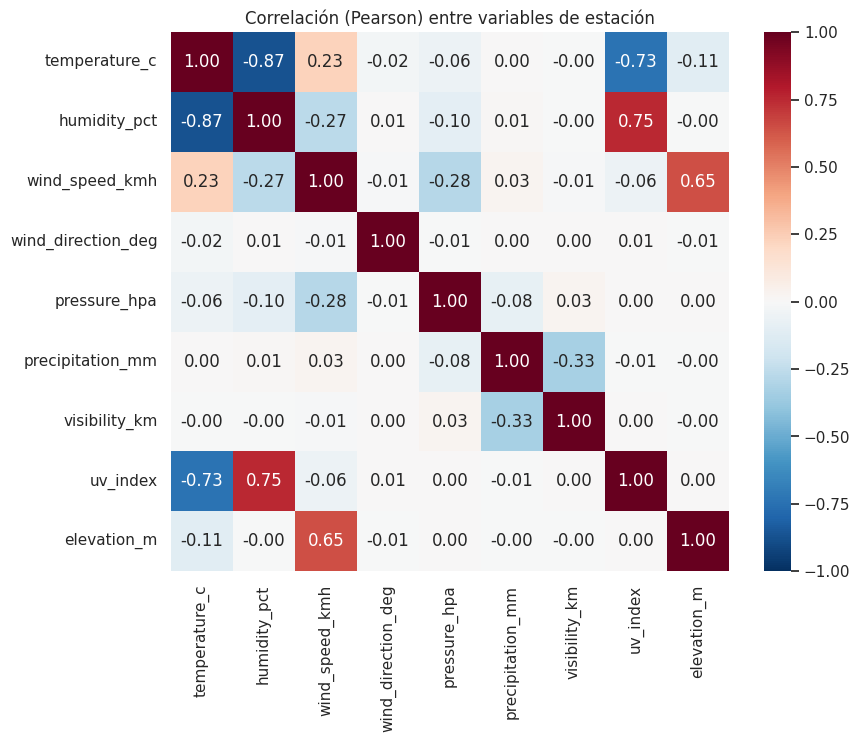

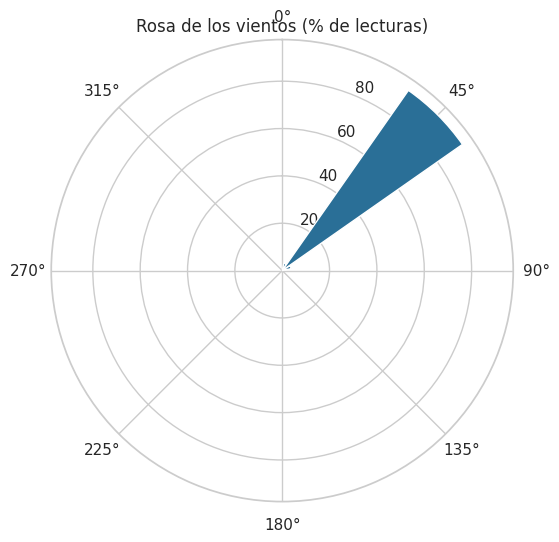

In [13]:
corr = df[VARS + ["elevation_m"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlación (Pearson) entre variables de estación"); plt.show()

# Rosa de los vientos
fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, polar=True)
bins = np.arange(-11.25, 360, 22.5)
h, _ = np.histogram(((df["wind_direction_deg"] + 11.25) % 360) - 11.25, bins=bins)
ax.bar(np.deg2rad(np.arange(0, 360, 22.5)), h / h.sum() * 100, width=np.deg2rad(20), color="#2a6f97")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_title("Rosa de los vientos (% de lecturas)"); plt.show()

## 5. Relación entre estaciones (espacial)

,station,lat,lon,elev,wind,temp,hum,pres
0,Alto Vista,12.59,-70.04,25,6.55,29.75,74.83,1015.40
1,Arikok National Park,12.50,-69.95,120,7.84,29.02,75.09,1015.41
2,Hooiberg Summit,12.52,-70.00,165,8.36,28.68,74.95,1015.44
3,Malmok,12.60,-70.05,6,6.22,29.71,74.91,1015.44
4,Noord,12.56,-70.03,15,6.28,29.60,74.90,1015.47
5,Oranjestad Central,12.52,-70.04,5,6.26,29.71,74.91,1015.42
6,Palm Beach,12.56,-70.04,3,6.15,29.76,75.21,1015.38
7,Paradera,12.54,-70.00,30,6.59,29.52,74.98,1015.47
8,Queen Beatrix Airport,12.50,-70.00,18,6.40,29.60,75.03,1015.43
9,San Nicolaas,12.44,-69.91,8,6.23,29.46,75.06,1015.41


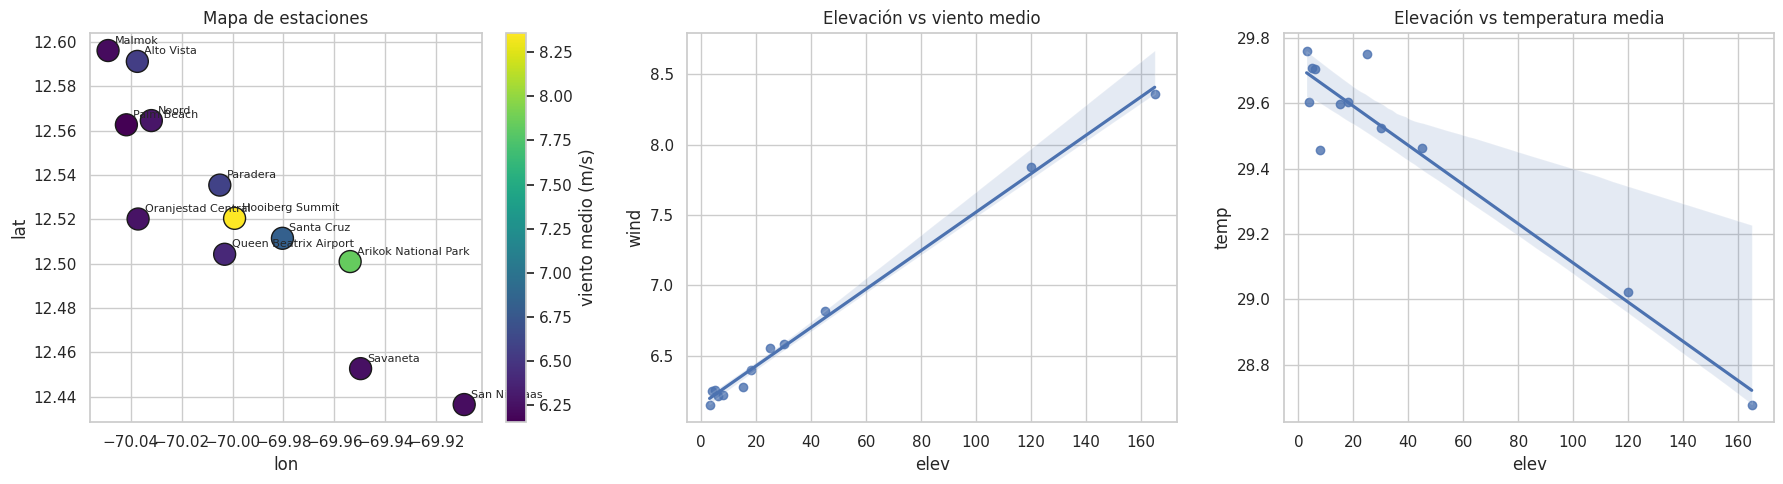

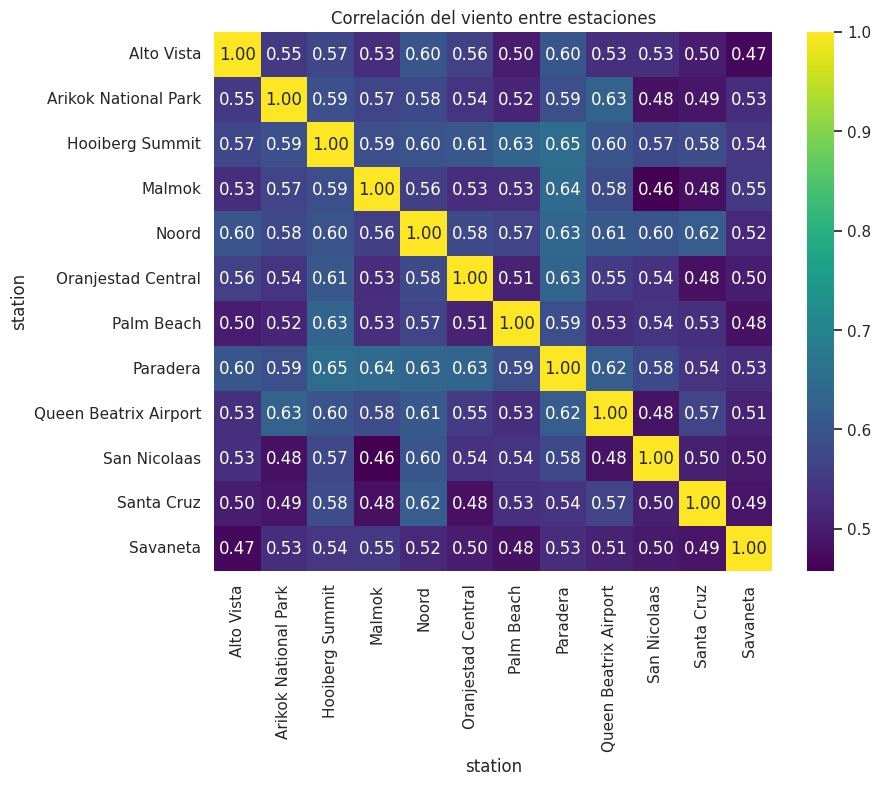

In [14]:
est = df.groupby("station").agg(lat=("latitude", "first"), lon=("longitude", "first"),
                                elev=("elevation_m", "first"), wind=("wind_ms", "mean"),
                                temp=("temperature_c", "mean"), hum=("humidity_pct", "mean"),
                                pres=("pressure_hpa", "mean")).reset_index()
display(est.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc = axes[0].scatter(est["lon"], est["lat"], c=est["wind"], s=250, cmap="viridis", edgecolor="k")
for _, r in est.iterrows(): axes[0].annotate(r["station"], (r["lon"], r["lat"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
plt.colorbar(sc, ax=axes[0], label="viento medio (m/s)"); axes[0].set_title("Mapa de estaciones")
axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")
sns.regplot(data=est, x="elev", y="wind", ax=axes[1]); axes[1].set_title("Elevación vs viento medio")
sns.regplot(data=est, x="elev", y="temp", ax=axes[2]); axes[2].set_title("Elevación vs temperatura media")
plt.tight_layout(); plt.show()

# Correlación del viento entre estaciones (serie cada 5 min alineada)
W = (df.assign(t=df["timestamp"].dt.floor("5min"))
       .pivot_table(index="t", columns="station", values="wind_ms", aggfunc="mean"))
plt.figure(figsize=(9, 7))
sns.heatmap(W.corr(), annot=True, fmt=".2f", cmap="viridis", vmin=W.corr().min().min(), vmax=1)
plt.title("Correlación del viento entre estaciones"); plt.show()

## 6. Fuente 1: ERA5 (viento 100 m + radiación)
El CSV puede ser muy grande (desde 1940), así que se lee **por bloques**: se guarda (a) el detalle sólo en la ventana
de las lecturas y (b) una climatología agregada (año-mes-hora) de todo el histórico.

In [15]:
t0, t1 = df["timestamp"].min().floor("D") - pd.Timedelta(days=2), df["timestamp"].max().ceil("D") + pd.Timedelta(days=2)
ventana, clim = [], []
for ch in pd.read_csv(PATH_ERA5, chunksize=2_000_000,
                      dtype={"latitude": "float32", "longitude": "float32", "u100": "float32",
                             "v100": "float32", "ssrd": "float32"}):
    ch["valid_time"] = pd.to_datetime(ch["valid_time"], utc=True, errors="coerce")
    ch["ws100"] = np.hypot(ch["u100"], ch["v100"])
    ch["ssrd_wm2"] = ch["ssrd"] / 3600.0          # J/m² acumulados en 1 h -> W/m² medios
    g = ch.groupby([ch.valid_time.dt.year.rename("y"), ch.valid_time.dt.month.rename("m"),
                    ch.valid_time.dt.hour.rename("h")])[["ws100", "ssrd_wm2", "u100", "v100"]].agg(["sum", "count"])
    clim.append(g)
    ventana.append(ch[(ch.valid_time >= t0) & (ch.valid_time <= t1)])
era = pd.concat(ventana, ignore_index=True)
print("ERA5 en la ventana de las lecturas:", era.shape)

c = pd.concat(clim)
c.columns = ["_".join(x) for x in c.columns]
c = c.groupby(level=[0, 1, 2]).sum()
clim = pd.DataFrame({"ws100": c.ws100_sum / c.ws100_count, "ssrd_wm2": c.ssrd_wm2_sum / c.ssrd_wm2_count}).reset_index()
print("Climatología agregada:", clim.shape)

# Nota: el ssrd vacío en las primeras filas es normal (ERA5 no lo da en el primer paso de la serie)
if len(era):
    display(era.describe().T.round(2))
    print("Nulos ERA5 (ventana):\n", era.isna().mean().round(3))
    print("Puntos de rejilla:", era[["latitude", "longitude"]].drop_duplicates().shape[0])

ERA5 en la ventana de las lecturas: (20745, 8)
Climatología agregada: (24984, 5)


,count,mean,std,min,25%,50%,75%,max
latitude,20745.0,12.50,0.20,12.25,12.25,12.50,12.75,12.75
longitude,20745.0,-70.00,0.20,-70.25,-70.25,-70.00,-69.75,-69.75
u100,20745.0,-11.49,2.38,-17.33,-13.19,-12.02,-10.16,-2.63
v100,20745.0,0.02,1.72,-5.33,-1.25,0.13,1.34,4.82
ssrd,20745.0,1007373.56,1248541.00,0.00,0.00,110592.00,2152768.00,3664512.00
ws100,20745.0,11.63,2.34,2.80,10.32,12.12,13.30,17.33
ssrd_wm2,20745.0,279.83,346.81,0.00,0.00,30.72,597.99,1017.92


Nulos ERA5 (ventana):
 valid_time    0.0
latitude      0.0
longitude     0.0
u100          0.0
v100          0.0
ssrd          0.0
ws100         0.0
ssrd_wm2      0.0
dtype: float64
Puntos de rejilla: 9


In [ ]:
# Contexto climatológico: viento y radiación por mes y por hora (todo el histórico) – válido aunque no solape con las lecturas
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
(clim.groupby("m").apply(lambda x: np.average(x.ws100)).plot(ax=axes[0], marker="o", color="#2a6f97"))
axes[0].set_title("ERA5: viento 100 m medio por mes (m/s)"); axes[0].set_xlabel("mes")
(clim.groupby("h").apply(lambda x: np.average(x.ws100)).plot(ax=axes[1], marker="o", color="#2a6f97"))
axes[1].set_title("ERA5: viento 100 m por hora UTC"); axes[1].set_xlabel("hora UTC")
(clim.groupby("h").apply(lambda x: np.nanmean(x.ssrd_wm2)).plot(ax=axes[2], marker="o", color="#e07a1f"))
axes[2].set_title("ERA5: radiación solar por hora UTC (W/m²)"); axes[2].set_xlabel("hora UTC")
plt.tight_layout(); plt.show()

anual = clim.groupby("y").ws100.mean()
plt.figure(figsize=(14, 3.5)); anual.plot(color="#2a6f97"); plt.title("ERA5: viento a 100 m medio anual (m/s)"); plt.show()

## 7. Integración estaciones ↔ ERA5
Cada estación se asocia al punto de rejilla ERA5 más cercano, y ambas series se llevan a paso horario.

In [16]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0; p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2-p1)/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(np.radians(lon2-lon1)/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

if len(era) == 0:
    print("⚠️ El CSV ERA5 no tiene datos en el periodo de las lecturas "
          f"({t0:%Y-%m-%d} → {t1:%Y-%m-%d}). Descarga ese tramo (ERA5 tiene ~5 días de retraso) o usa Open-Meteo para completarlo.")
    merged = pd.DataFrame()
else:
    grid = era[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
    est["grid_idx"] = [haversine(r.lat, r.lon, grid.latitude.values, grid.longitude.values).argmin() for r in est.itertuples()]
    est["grid_lat"] = grid.latitude.values[est.grid_idx]; est["grid_lon"] = grid.longitude.values[est.grid_idx]
    est["dist_km"] = haversine(est.lat, est.lon, est.grid_lat, est.grid_lon)
    display(est[["station", "lat", "lon", "grid_lat", "grid_lon", "dist_km"]].round(3))

    era_h = era.rename(columns={"valid_time": "t"}).set_index(["t", "latitude", "longitude"])
    sh = (df.assign(t=df["timestamp"].dt.floor("1h"))
            .groupby(["station", "t"])[["wind_ms", "wind100_est_ms", "wind_direction_deg", "temperature_c",
                                         "humidity_pct", "uv_index", "pressure_hpa"]].mean().reset_index())
    sh = sh.merge(est[["station", "grid_lat", "grid_lon"]], on="station")
    merged = sh.merge(era.rename(columns={"valid_time": "t", "latitude": "grid_lat", "longitude": "grid_lon"})
                        [["t", "grid_lat", "grid_lon", "u100", "v100", "ws100", "ssrd_wm2"]],
                      on=["t", "grid_lat", "grid_lon"], how="inner")
    merged["dir100"] = (270 - np.degrees(np.arctan2(merged.v100, merged.u100))) % 360   # dirección meteorológica "de dónde viene"
    print("Filas integradas (estación-hora):", merged.shape)
    display(merged.head())

,station,lat,lon,grid_lat,grid_lon,dist_km
0,Alto Vista,12.591,-70.037,12.5,-70.0,10.923
1,Arikok National Park,12.501,-69.954,12.5,-70.0,5.016
2,Hooiberg Summit,12.520,-69.999,12.5,-70.0,2.270
3,Malmok,12.596,-70.049,12.5,-70.0,11.931
4,Noord,12.564,-70.032,12.5,-70.0,7.964
5,Oranjestad Central,12.520,-70.037,12.5,-70.0,4.606
6,Palm Beach,12.563,-70.042,12.5,-70.0,8.303
7,Paradera,12.535,-70.005,12.5,-70.0,3.974
8,Queen Beatrix Airport,12.504,-70.003,12.5,-70.0,0.576
9,San Nicolaas,12.436,-69.909,12.5,-70.0,12.150


Filas integradas (estación-hora): (26208, 16)


,station,t,wind_ms,wind100_est_ms,wind_direction_deg,temperature_c,humidity_pct,uv_index,pressure_hpa,grid_lat,grid_lon,u100,v100,ws100,ssrd_wm2,dir100
0,Alto Vista,2026-03-31 22:00:00+00:00,6.041667,8.394869,46.258333,30.716667,70.783333,0.0,1015.941667,12.5,-70.0,-8.948776,-2.416748,9.269373,250.631104,74.886963
1,Alto Vista,2026-03-31 23:00:00+00:00,6.252315,8.687563,43.816667,31.483333,68.941667,0.0,1015.900000,12.5,-70.0,-9.413086,-2.616745,9.770033,42.844444,74.464600
2,Alto Vista,2026-04-01 00:00:00+00:00,6.486111,9.012422,43.225000,32.283333,67.816667,0.0,1015.908333,12.5,-70.0,-9.539795,-2.788818,9.939075,0.000000,73.704468
3,Alto Vista,2026-04-01 01:00:00+00:00,6.747685,9.375878,46.041667,32.350000,66.991667,0.0,1016.000000,12.5,-70.0,-9.741394,-2.743027,10.120225,0.000000,74.273560
4,Alto Vista,2026-04-01 02:00:00+00:00,6.976852,9.694304,47.366667,32.075000,66.416667,0.0,1015.991667,12.5,-70.0,-10.133194,-2.692947,10.484921,0.000000,75.117371


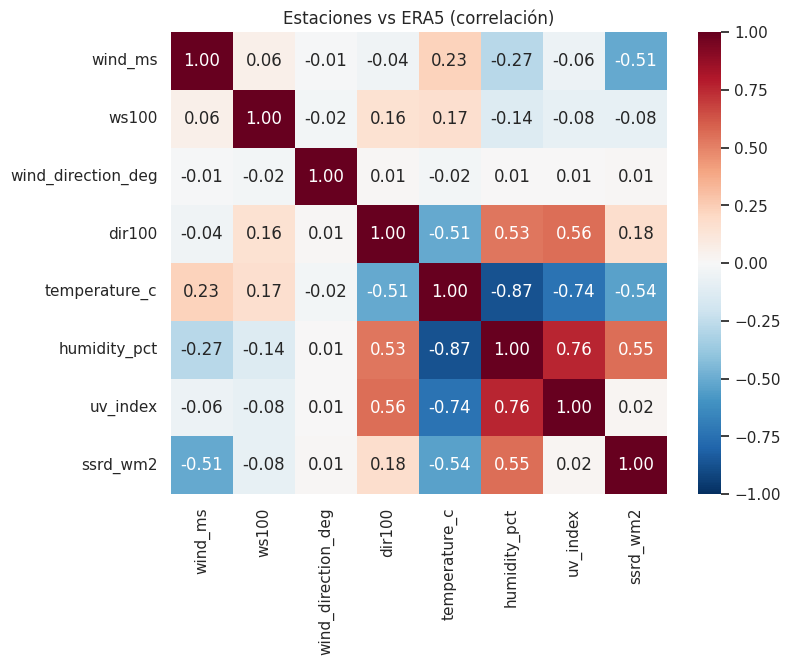

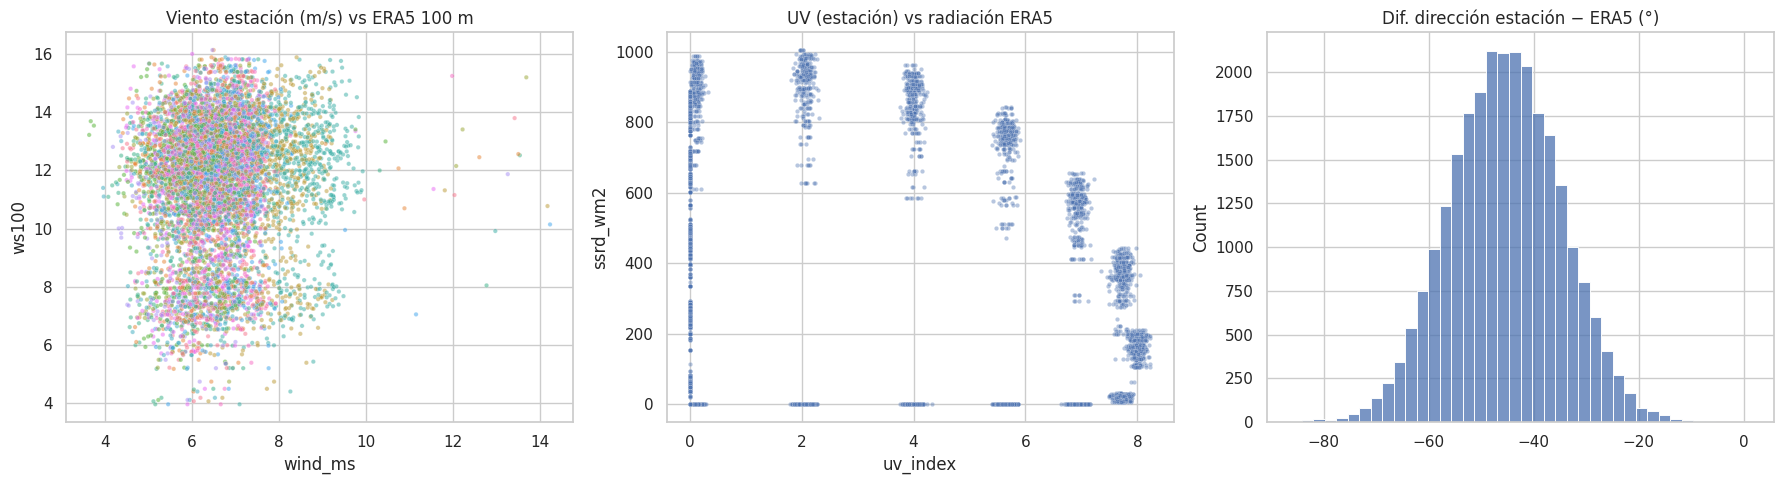

,corr_viento,ratio_ERA5/estación,alpha_implícito,RMSE_vs_ERA5_100m_est
station,,,,
Alto Vista,0.033,1.829,0.262,3.566
Arikok National Park,0.070,1.535,0.186,2.569
Hooiberg Summit,0.092,1.434,0.157,2.417
Malmok,0.069,1.932,0.286,3.873
Noord,0.109,1.908,0.281,3.761
Oranjestad Central,0.151,1.915,0.282,3.786
Palm Beach,0.078,1.949,0.290,3.944
Paradera,0.096,1.813,0.258,3.454
Queen Beatrix Airport,0.091,1.866,0.271,3.660


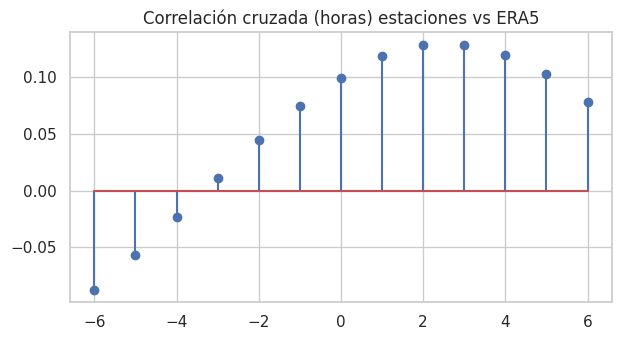

In [17]:
if len(merged):
    cols = ["wind_ms", "ws100", "wind_direction_deg", "dir100", "temperature_c", "humidity_pct", "uv_index", "ssrd_wm2"]
    plt.figure(figsize=(8, 6))
    sns.heatmap(merged[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
    plt.title("Estaciones vs ERA5 (correlación)"); plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(data=merged.sample(min(len(merged), 8000), random_state=0), x="wind_ms", y="ws100",
                    hue="station", s=10, alpha=.5, ax=axes[0], legend=False)
    axes[0].set_title("Viento estación (m/s) vs ERA5 100 m")
    sns.scatterplot(data=merged.sample(min(len(merged), 8000), random_state=0), x="uv_index", y="ssrd_wm2",
                    s=10, alpha=.4, ax=axes[1]); axes[1].set_title("UV (estación) vs radiación ERA5")
    # dirección circular: diferencia mínima
    d = ((merged.wind_direction_deg - merged.dir100 + 180) % 360) - 180
    sns.histplot(d, bins=40, ax=axes[2]); axes[2].set_title("Dif. dirección estación − ERA5 (°)")
    plt.tight_layout(); plt.show()

    # Relación por estación + exponente de cizalladura implícito
    rel = merged.groupby("station").apply(lambda g: pd.Series({
        "corr_viento": g.wind_ms.corr(g.ws100),
        "ratio_ERA5/estación": (g.ws100 / g.wind_ms.replace(0, np.nan)).median(),
        "alpha_implícito": np.log((g.ws100 / g.wind_ms.replace(0, np.nan)).median()) / np.log(ALTURA_BUJE_M / ALTURA_MEDIDA_ESTACION_M),
        "RMSE_vs_ERA5_100m_est": np.sqrt(((g.wind100_est_ms - g.ws100) ** 2).mean())})).round(3)
    display(rel)

    # Desfases temporales (¿ERA5 adelanta/atrasa respecto a las estaciones?)
    prom = merged.groupby("t")[["wind_ms", "ws100"]].mean()
    lags = range(-6, 7)
    cc = [prom.wind_ms.corr(prom.ws100.shift(l)) for l in lags]
    plt.figure(figsize=(7, 3.5)); plt.stem(list(lags), cc); plt.title("Correlación cruzada (horas) estaciones vs ERA5"); plt.show()

## 8. Primer vistazo a la variable objetivo: potencia del parque
⚠️ **Curva de potencia genérica** de una turbina de 3 MW (arranque 3.5 m/s, nominal ~13 m/s, corte 25 m/s).
Sustitúyela por la de la ficha del fabricante (tarea 2.4 del plan).

Fuente de viento a altura de buje: ERA5 100 m
Potencia media: 23326 kW | factor de capacidad: 77.8%
% del tiempo < 500 kW: 0.0%
Percentil 15 de potencia: 11520 kW


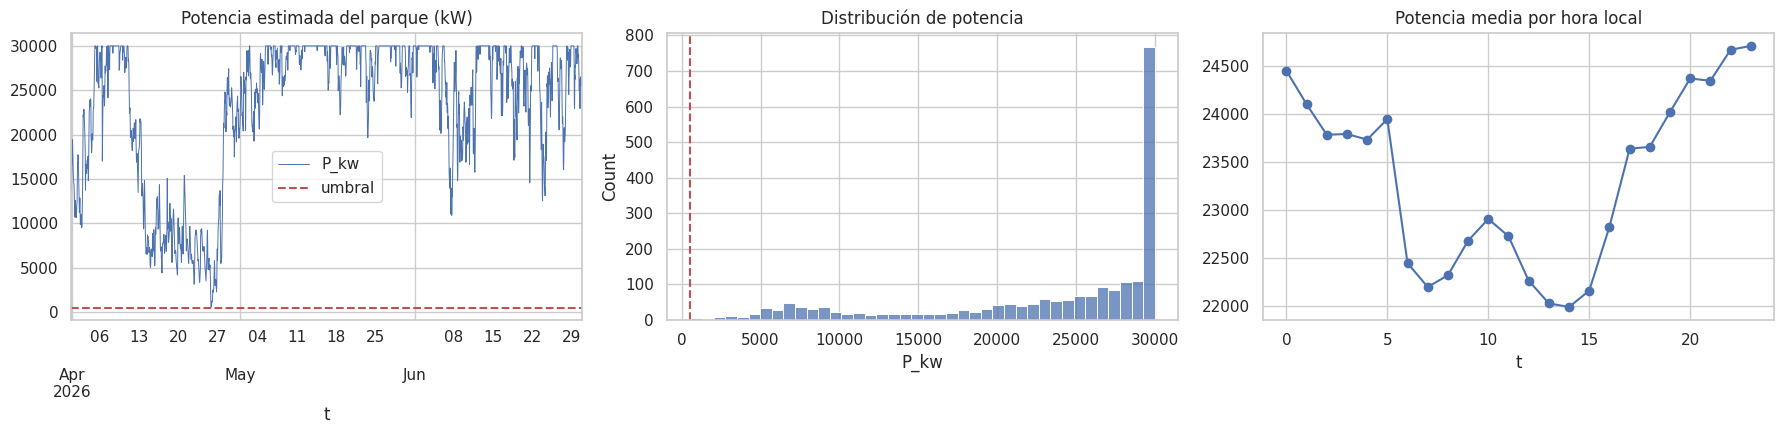

In [18]:
ws_pts  = [0, 3.5, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 25, 25.01, 40]
kw_pts  = [0, 0, 60, 190, 350, 580, 880, 1250, 1700, 2200, 2650, 3000, 3000, 0, 0]
def potencia_parque_kw(ws):
    return N_TURBINAS * np.interp(ws, ws_pts, kw_pts)

base = merged.assign(viento_hub=merged.ws100) if len(merged) else df.assign(viento_hub=df.wind100_est_ms)
fuente_hub = "ERA5 100 m" if len(merged) else "estaciones extrapoladas a 100 m (ley 1/7)"
base["P_kw"] = potencia_parque_kw(base["viento_hub"])
print("Fuente de viento a altura de buje:", fuente_hub)

col_t = "t" if "t" in base else "timestamp"
serie_p = base.groupby(col_t)["P_kw"].mean()
print(f"Potencia media: {serie_p.mean():.0f} kW | factor de capacidad: {serie_p.mean()/(N_TURBINAS*P_NOMINAL_KW):.1%}")
print(f"% del tiempo < {UMBRAL_ALERTA_KW} kW: {(serie_p < UMBRAL_ALERTA_KW).mean():.1%}")
print(f"Percentil 15 de potencia: {serie_p.quantile(.15):.0f} kW")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
serie_p.plot(ax=axes[0], lw=.7); axes[0].axhline(UMBRAL_ALERTA_KW, color="r", ls="--", label="umbral"); axes[0].legend()
axes[0].set_title("Potencia estimada del parque (kW)")
sns.histplot(serie_p, bins=40, ax=axes[1]); axes[1].axvline(UMBRAL_ALERTA_KW, color="r", ls="--"); axes[1].set_title("Distribución de potencia")
serie_p.groupby(serie_p.index.tz_convert(TZ_LOCAL).hour).mean().plot(ax=axes[2], marker="o"); axes[2].set_title("Potencia media por hora local")
plt.tight_layout(); plt.show()

## 9. Predictibilidad a 15 min (persistencia + autocorrelación)
Referencia mínima que tendrán que batir los modelos (RF-10).

In [19]:
W5 = W.resample("5min").mean()                         # rejilla de 5 min (RF-04)
print("Huecos en rejilla de 5 min tras remuestreo:", int(W5.isna().sum().sum()))
W5 = W5.interpolate(limit=3)                           # sólo huecos cortos (≤15 min)
v5 = W5.mean(axis=1) * (ALTURA_BUJE_M / ALTURA_MEDIDA_ESTACION_M) ** (1/7)
P5 = pd.Series(potencia_parque_kw(v5.values), index=v5.index).where(v5.notna())

lags5 = [1, 2, 3, 4, 6, 12]                            # 5,10,15,20,30,60 min
ac = {f"{5*l} min": P5.autocorr(l) for l in lags5}
display(pd.Series(ac, name="autocorrelación potencia").round(3).to_frame())

y = P5.shift(-3); ok = y.notna() & P5.notna()
rmse = np.sqrt(((y[ok] - P5[ok]) ** 2).mean()); r2 = 1 - ((y[ok]-P5[ok])**2).sum() / ((y[ok]-y[ok].mean())**2).sum()
print(f"Persistencia t+15 min → RMSE = {rmse:.1f} kW | R² = {r2:.3f}   (línea base a superar)")

Huecos en rejilla de 5 min tras remuestreo: 0


,autocorrelación potencia
5 min,0.999
10 min,0.998
15 min,0.997
20 min,0.995
30 min,0.989
60 min,0.960


Persistencia t+15 min → RMSE = 286.9 kW | R² = 0.994   (línea base a superar)


## 10. Conclusiones para el pipeline (completa con tus hallazgos)
- Frecuencia de muestreo real y huecos → define el remuestreo a 5 min.
- Duplicados / valores fuera de rango → reglas de limpieza (RF-03).
- Correlación entre estaciones → ¿promediar o usar cada estación como feature?
- Relación estación ↔ ERA5 (ratio, α implícito, desfase) → cómo corregir el viento a buje.
- Potencia estimada, % < 500 kW y P15 → umbrales de alerta.
- RMSE/R² de persistencia → línea base para los modelos de regresión.